# **Comparing DBSCAN and HDBSCAN Clustering**

### Objectives
* Use scikit-learn to implement DBSCAN and HDBSCAN clustering models to real data
* Compare the performances of the two models

### Introduction
We'll create two clustering models using data curated by StatCan containing the names, types, and locations of cultural and art facilities accross Canada. We'll focus on the museum locations provided across Canada.

#### Data source: The Opem Database of Cultural and Art Facilities (ODCAF)
A collection of open data containing the names, types, and locations of cultural and art facilities across Canada. It is released under the Open Government License - Canada.

* [Landing Page](https://www.statcan.gc.ca/en/lode/databases/odcaf)
* [Zip File](https://www150.statcan.gc.ca/n1/en/pub/21-26-0001/2020001/ODCAF_V1.0.zip?st=brOCT3Ry)

---

#### Import the Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

#### Download the Canada map for reference

In [2]:
import requests
import io
import zipfile
import os

# URL of the ZIP file on the cloud server
zip_path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YcUk-ytgrPkmvZAh5bf7zA/Canada.zip'

# Make directory for the downloaded file
out_dir = './'
os.makedirs(out_dir, exist_ok=True)

# Download the ZIP file
response = requests.get(zip_path)
response.raise_for_status() # Error handling

# Open the ZIP file
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_file:
    for file_name in zip_file.namelist():
        if file_name.endswith('.tif'):
            zip_file.extract(file_name, out_dir)
            print(f"Downloaded and extracted! {file_name}")

Downloaded and extracted! Canada.tif


#### Include a plotting function
The code for a helper function is provided to help you plot your results. Although you don't need to worry about the details, it's quite instructive as it uses a geopandas dataframe and a basemap to plot coloured cluster points on a map of Canada.

In [3]:
import geopandas as gpd
import contextily as ctx
# Function that plots clustered locations and overlays them on a basemap.

def plot_clustered_locations(df, title='Museums Clustered by Proximity'):
    """
    Plots clustered locations and overlays on a basemap

    Parameters:
    - df: DataFrame containing 'Latitude', 'Longitude', and 'Cluster' columns
    - title: str, title of the plot
    """

    # Load the coordinates into a GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs="EPSG:4326")

    # Reproject to Web Mercator to aling with basemap
    gdf = gdf.to_crs(epsg=3857)

    # Create the plot
    fig, ax = plt.subplots(figsize=(15, 10))

    # Sepearate non-noise, or clustered points from noise, or unclustered points
    non_noise = gdf[gdf['Cluster'] != -1]
    noise = gdf[gdf['Cluster'] == -1]

    # Plot noise points
    noise.plot(ax=ax, color='k', markersize=30, ec='r', alpha=1, label='Noise')

    # Plot clustered points, coloured by 'Cluster' number
    non_noise.plot(ax=ax, column='Cluster', cmap='tab10', markersize=30, ec='k', legend=False, alpha=0.6)

    # Add basemap of Canada
    ctx.add_basemap(ax, source='./Canada.tif', zoom=4)

    # Format plot
    plt.title(title, )
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()

    plt.show()


#### Explore the data

In [4]:
df = pd.read_csv('ODCAF_v1.0.csv', encoding="ISO-8859-1")
df.head()

,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
0,1,#Hashtag Gallery,..,gallery,toronto,..,801,dundas st w,M6J 1V2,toronto,on,801 dundas st w,Toronto,3520005,35,43.65169472,-79.40803272
1,2,'Ksan Historical Village & Museum,historic site-building or park,museum,canadian museums association,..,1500,62 hwy,V0J 1Y0,hazelton,bc,1500 hwy 62 hazelton british columbia v0j 1y0 ...,Hazelton,5949022,59,55.2645508,-127.6428124
2,3,'School Days' Museum,community/regional museum,museum,canadian museums association,..,427,queen st,E3B 5R6,fredericton,nb,427 queen st fredericton new brunswick e3b 5r6...,Fredericton,1310032,13,45.963283,-66.6419017
3,4,10 Austin Street,built heritage properties,heritage or historic site,moncton,..,10,austin st,E1C 1Z6,moncton,nb,10 austin st,Moncton,1307022,13,46.09247776,-64.78022946
4,5,10 Gates Dancing Inc.,arts,miscellaneous,ottawa,..,..,..,..,ottawa,on,..,Ottawa,3506008,35,45.40856224,-75.71536766


In [5]:
(df == '..').sum()

Index                       0
Facility_Name               4
Source_Facility_Type     2533
ODCAF_Facility_Type         0
Provider                    0
Unit                     7623
Street_No                1284
Street_Name              1149
Postal_Code              1454
City                      116
Prov_Terr                   2
Source_Format_Address     804
CSD_Name                  301
CSDUID                    301
PRUID                      90
Latitude                 1224
Longitude                1224
dtype: int64

In [6]:
df.ODCAF_Facility_Type.value_counts()

ODCAF_Facility_Type
library or archives                     3013
museum                                  1938
gallery                                  810
heritage or historic site                620
theatre/performance and concert hall     583
festival site                            346
miscellaneous                            343
art or cultural centre                   225
artist                                    94
Name: count, dtype: int64

In [7]:
df = df[df.ODCAF_Facility_Type == 'museum']
df.shape[0]

1938

In [8]:
df = df[['Latitude', 'Longitude']]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1938 entries, 1 to 7969
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Latitude   1938 non-null   object
 1   Longitude  1938 non-null   object
dtypes: object(2)
memory usage: 45.4+ KB


In [9]:
df = df.replace('..', np.nan).dropna()
df[['Latitude', 'Longitude']] = df[['Latitude', 'Longitude']].astype('float')

---

### Build a DBSCAN model

#### First we find the best parameters for the DBSCAN using KNN model

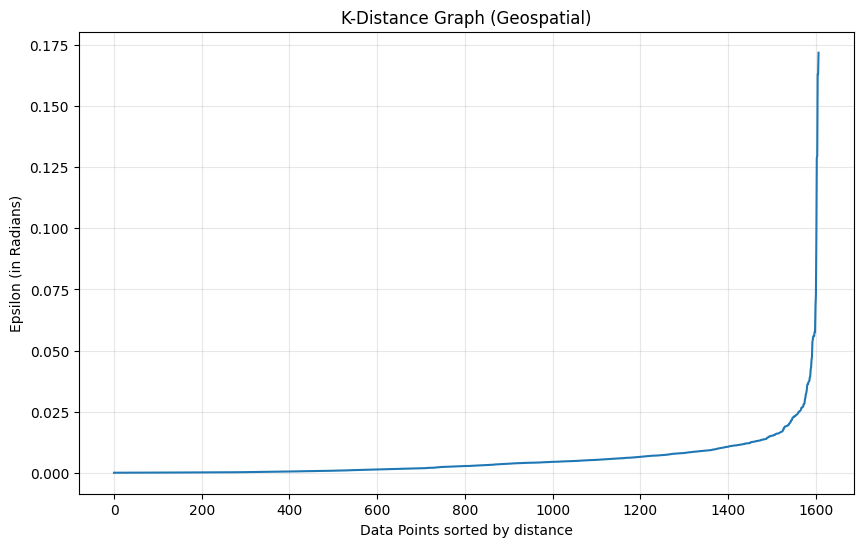

In [10]:
from sklearn.neighbors import NearestNeighbors

# Prepare the Data (convert to radians)
# Scikit-Learns's Haversine metric requires Radians, not Degrees
coords_rad = np.radians(df[['Latitude', 'Longitude']])

# Configure Nearest Neighbors
# metric = 'haversine' calculates distance on a sphere (Earth)
# n_neighbors = 5 (Standard rule of thumb for 2D spatial data)
nbrs = NearestNeighbors(n_neighbors=5, metric='haversine').fit(coords_rad)

# Calculate Distances
distance, indices = nbrs.kneighbors(coords_rad)


# Sort and Plot
distance = np.sort(distance[:, 4], axis=0) # Take the 5th neighbor

plt.figure(figsize=(10,6))
plt.plot(distance)
plt.title('K-Distance Graph (Geospatial)')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon (in Radians)')
plt.grid(True, alpha=0.3)
plt.show()

#### Apply DBSCAN with Haversine distance to the scaled coordinates

In [11]:
from sklearn.cluster import DBSCAN

# Define the model
dbscan = DBSCAN(eps=0.003, min_samples=5, metric='haversine', algorithm='ball_tree')
dbscan.fit(coords_rad)
labels = dbscan.labels_  # Get the labels

# Check the results
# -1 means 'Noise' (Rural/Remote Facilities)
# else are the Clusters (Cities/Towns)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Estimated number of clusters: {n_clusters}")
print(f"Percentage of noise points: {(n_noise/coords_rad.shape[0]):.2%}")

Estimated number of clusters: 51
Percentage of noise points: 43.87%


In [12]:
df['Cluster'] = dbscan.fit_predict(coords_rad) # Assign the cluster labels

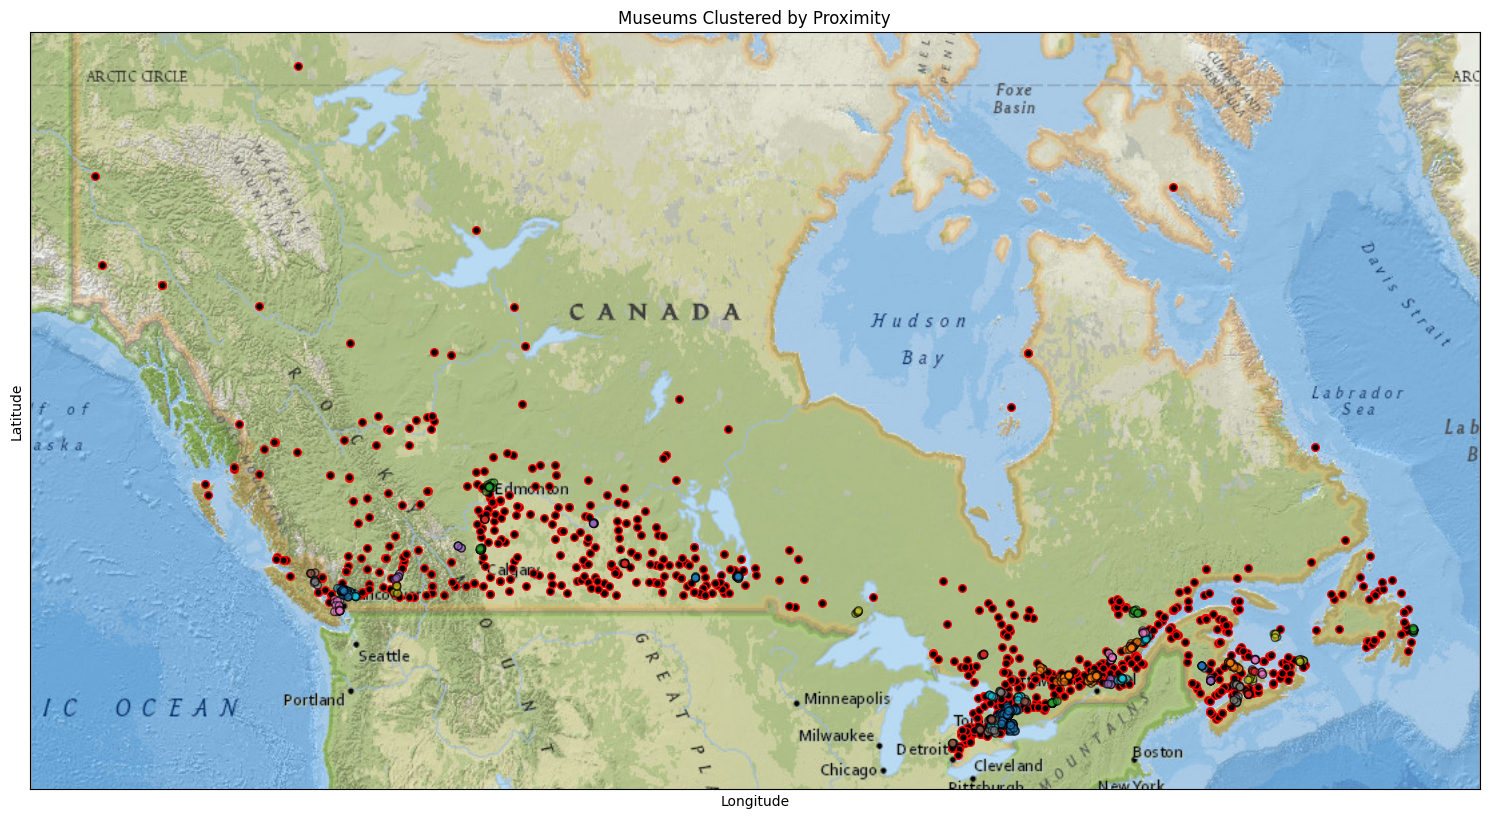

In [13]:

plot_clustered_locations(df, title='Museums Clustered by Proximity')

One key thing to notice here is that the clusters are not uniformly dense.

For example, the points are quite densely packed in a few regions but are relatively sparse in between.

DBSCAN agglomerates neighboring clusters together when they are close enough

Let's see how a hierarchical density-based clustering algorithm like HDBSCAN performs.

---

#### Build an HDBSCAN Clustering Model

In [14]:
from sklearn.cluster import HDBSCAN

# Initialize an HDBSCAN Model
hdb = HDBSCAN(min_cluster_size=5, 
              metric='haversine', 
              cluster_selection_method='eom') # 'eom' stands for 'Excess of Mass'

hdb.fit(coords_rad)

# Results
h_labels = hdb.labels_
h_clusters = len(set(h_labels)) - (1 if -1 in h_labels else 0)
h_noise = list(h_labels).count(-1)

print(f"HDBSCAN discovered {h_clusters} clusters")
print(f"Noise reduction: {((n_noise - h_noise)/ n_noise):.2%}")

HDBSCAN discovered 88 clusters
Noise reduction: 30.64%


In [15]:
df['Cluster'] = hdb.fit_predict(coords_rad)

df

,Latitude,Longitude,Cluster
1,55.264551,-127.642812,2
2,45.963283,-66.641902,21
8,49.176354,-123.112783,-1
13,49.261938,-123.151123,82
15,49.889559,-97.235744,70
...,...,...,...
7934,43.183090,-79.224564,80
7936,43.690022,-79.476208,86
7940,43.857692,-79.361940,86
7968,48.422420,-123.343553,66


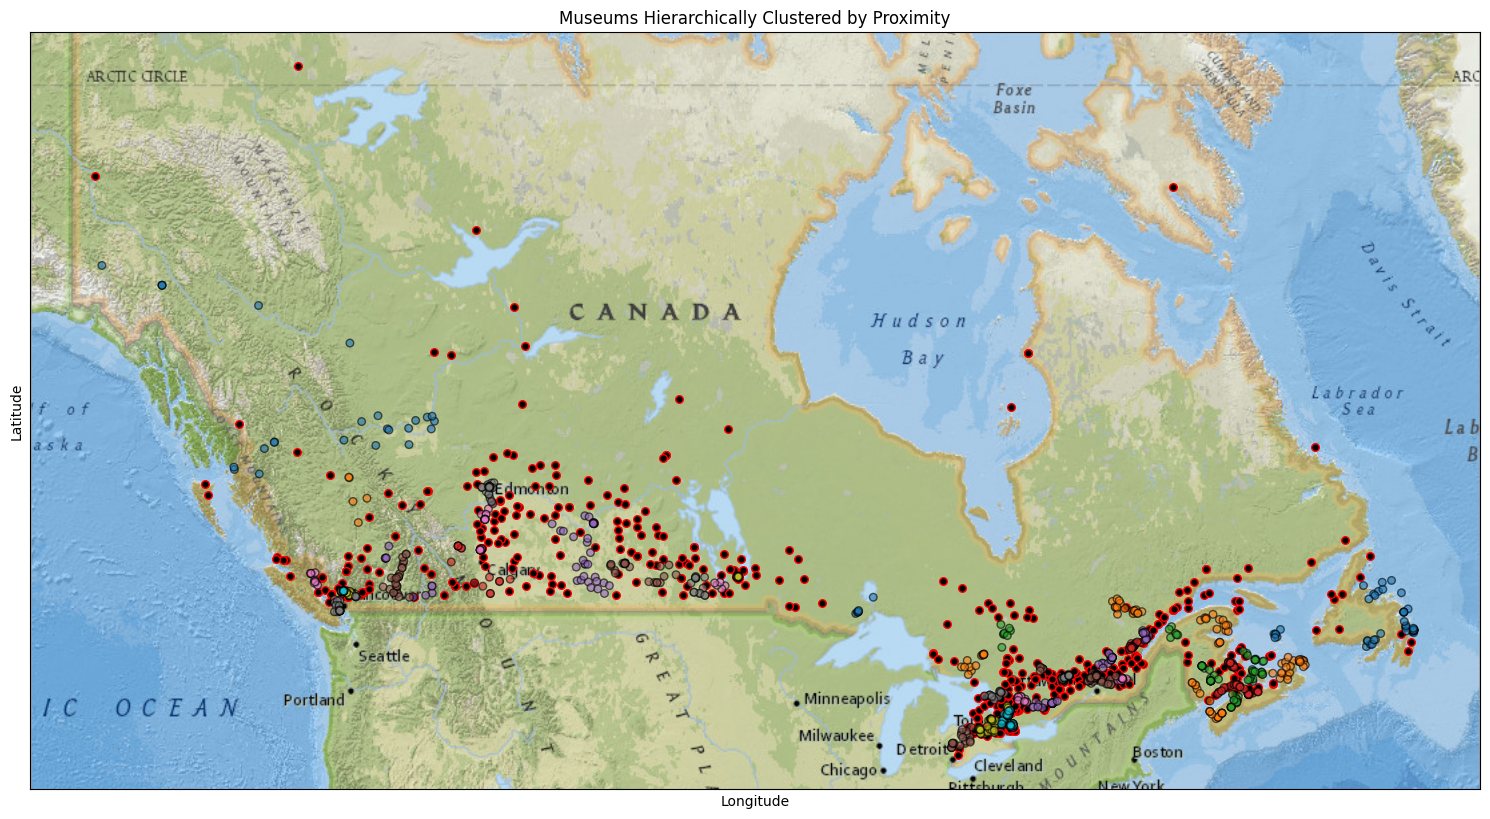

In [16]:
plot_clustered_locations(df, title='Museums Hierarchically Clustered by Proximity')

---

#### Finalize Result

In [21]:
# Add back the metadata
df_final = df.join(pd.read_csv('ODCAF_v1.0.csv', encoding="ISO-8859-1")[['City' ,'Prov_Terr', 'ODCAF_Facility_Type']])

# Dictionary to store the cluster names
cluster_name_map = {}

for label in set(h_labels):
    if label != -1:
        cluster_data = df_final[df_final['Cluster'] == label]

        # Find the most common City and Province
        city = cluster_data['City'].mode()[0]
        prov = cluster_data['Prov_Terr'].mode()[0]

        # Create a name
        cluster_name_map[label] = f"{city}, {prov}"
    else:
        cluster_name_map[label] = "Rural/Remote Area"

# Map it to main DataFrame
df_final['Cluster_Name'] = df_final['Cluster'].map(cluster_name_map)

# Check the result
print(df_final[['City', 'Cluster', 'Cluster_Name']].head())

           City  Cluster       Cluster_Name
1      hazelton        2       hazelton, bc
2   fredericton       21    fredericton, nb
8      richmond       -1  Rural/Remote Area
13    vancouver       82      vancouver, bc
15     winnipeg       70       winnipeg, mb


In [37]:
# See which cluster has most count (noises excluded)
profile = df_final[df_final['Cluster'] != -1]['Cluster_Name'].value_counts()

profile.head(10).to_frame()

,count
Cluster_Name,
"montréal, qc",89
"ottawa, on",85
"toronto, on",53
"vancouver, bc",45
"québec, qc",37
"edmonton, ab",31
"kingston, on",28
"winnipeg, mb",26
"victoria, bc",26


---

#### Changing Plotting to Folium

In [39]:
import folium
import matplotlib.cm as cm
import matplotlib.colors as colors

def create_map(df, cluster_col='Cluster'):
    # Initilize the Map centered on Canada
    canada_map = folium.Map(location=[56.130, -106.35], zoom_start=4, tiles='CartoDB dark_matter')

    # Color generator
    unique_clusters = df[cluster_col].unique()

    color_map = {}
    colormap = cm.get_cmap('tab20')

    for i, cluster in enumerate(sorted(unique_clusters)):
        if cluster == -1:
            color_map[cluster] = '#ff0000' # Red for Noise
        else:
            # modulo % 20 to cycle through the color palette
            rgba = colormap(i % 20)
            color_map[cluster] = colors.rgb2hex(rgba)

    # Add points to the map
    def add_point(row):
        # Determine color
        c_color = color_map.get(row[cluster_col], '#ffffff')

        # Tooltip Text
        if 'Cluster_Name' in row:
            t_tip = f"{row['Cluster_Name']} (Cluster {row[cluster_col]})"
        else:
            t_tip = f"Cluster {row[cluster_col]}"

        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=4,
            color=c_color,
            fill=True,
            fill_color=c_color,
            fill_opacity=0.7,
            popup=f"<b>{row['ODCAF_Facility_Type']}</b><br>{row['City']}", # Click for details
            tooltip=t_tip
        ).add_to(canada_map)
    
    # Run the function on every row
    df.apply(add_point, axis=1)

    return canada_map


In [40]:
my_map = create_map(df_final, cluster_col='Cluster')

my_map